In [1]:
%reset -f
import pandas as pd
import numpy as np
from code import interact
import matplotlib.pyplot as plt

df = pd.read_csv("../debug/Maximum_Values.dat", delim_whitespace=True, header=0, usecols=[0, 6], names=['Time', 'U_Max_Mag'])
iterations = df['Time'].values
max_velocity = df['U_Max_Mag'].values


Total iterations: 1969
Iteration range: 100 to 178900
Max velocity magnitude range: 0.0394011 to 0.092801

Creating zoomed plot: iterations 5000 to 10000


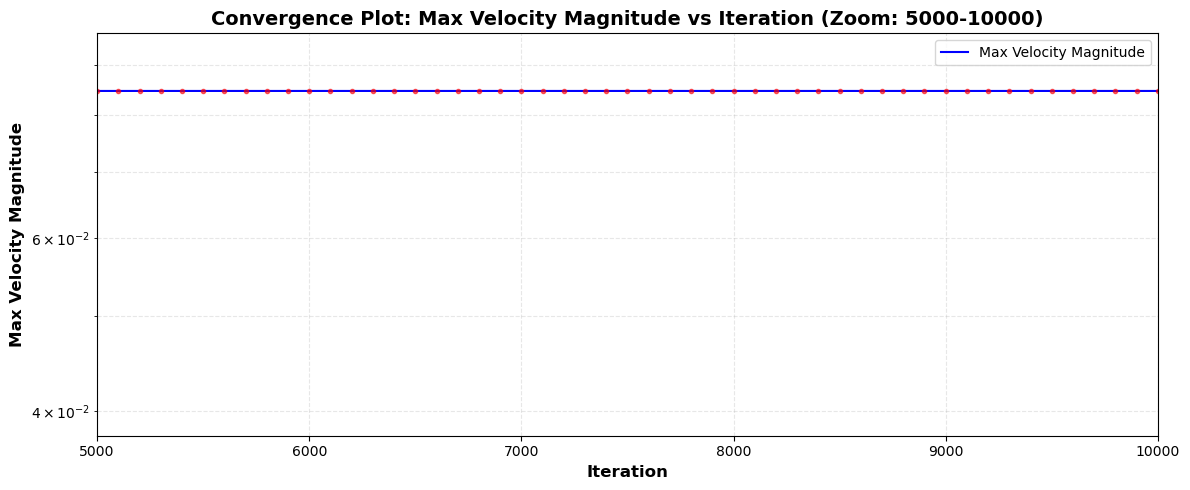

In [2]:
# Create convergence plot with zoom functionality
def plot_convergence(iterations, max_velocity, xlim=None, figsize=(12, 5)):
    """
    Plot convergence of Max Velocity Magnitude vs iterations
    
    Parameters:
    -----------
    iterations : array
        Iteration numbers
    max_velocity : array
        Max velocity magnitude values
    xlim : tuple, optional
        X-axis range (start, end) for zooming
    figsize : tuple
        Figure size (width, height)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot with markers and line
    ax.plot(iterations, max_velocity, 'b-', linewidth=1.5, label='Max Velocity Magnitude')
    ax.plot(iterations, max_velocity, 'ro', markersize=3, alpha=0.6)
    
    # Set labels and title
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Max Velocity Magnitude', fontsize=12, fontweight='bold')
    ax.set_title('Convergence Plot: Max Velocity Magnitude vs Iteration', fontsize=14, fontweight='bold')
    
    # Set log scale for y-axis (common for convergence plots)
    ax.set_yscale('log')
    
    # Add grid
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    
    # Apply zoom if specified
    if xlim is not None:
        ax.set_xlim(xlim)
        ax.set_title(f'Convergence Plot: Max Velocity Magnitude vs Iteration (Zoom: {xlim[0]}-{xlim[1]})', 
                     fontsize=14, fontweight='bold')
    
    # Add legend
    ax.legend(loc='best')
    
    plt.tight_layout()
    return fig, ax

# Plot 1: Full range
#fig1, ax1 = plot_convergence(iterations, l2_norm)
#plt.show()

print(f"\nTotal iterations: {len(iterations)}")
print(f"Iteration range: {iterations[0]} to {iterations[-1]}")
print(f"Max velocity magnitude range: {max_velocity.min()} to {max_velocity.max()}")

# Example zoom ranges (uncomment to use)
# zoom_ranges = [
#     (0, 100),      # First 100 iterations
#     (0, 500),      # First 500 iterations
#     (500, 1000),   # Iterations 500-1000
#     (1000, 2000),  # Iterations 1000-2000
# ]

# for xlim in zoom_ranges:
#     fig, ax = plot_convergence(iterations, max_velocity, xlim=xlim)
#     plt.show()

# Custom zoom range - modify the values below
zoom_start = 5000
zoom_end = 10000

print(f"\nCreating zoomed plot: iterations {zoom_start} to {zoom_end}")
fig2, ax2 = plot_convergence(iterations, max_velocity, xlim=(zoom_start, zoom_end))
plt.show()

In [3]:
from ipywidgets import interact, IntSlider

# INTERACTIVE WIDGET VERSION (uses existing ipywidgets imports: interact, IntSlider)

def interactive_convergence_plot(x_start, x_end):
    """Interactive plot with slider controls for zoom"""
    if x_start >= x_end:
        print("Error: x_start must be less than x_end")
        return

    # Convert to numeric (handles header row) and filter
    numeric_iters = pd.to_numeric(iterations, errors='coerce')
    numeric_max_velocity = pd.to_numeric(max_velocity, errors='coerce')

    mask = (numeric_iters >= x_start) & (numeric_iters <= x_end)
    filtered_iterations = numeric_iters[mask]
    filtered_max_velocity = numeric_max_velocity[mask]  
    if len(filtered_iterations) == 0:
        print(f"No data points in range [{x_start}, {x_end}]")
        return

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(filtered_iterations, filtered_max_velocity, 'b-', linewidth=1.5, label='Max Velocity Magnitude')
    ax.plot(filtered_iterations, filtered_max_velocity, 'ro', markersize=3, alpha=0.6)

    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Max Velocity Magnitude', fontsize=12, fontweight='bold')
    ax.set_title(f'Convergence Plot: Iterations {int(filtered_iterations[0])} to {int(filtered_iterations[-1])}', 
                 fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.legend(loc='best')

    fig.tight_layout()
    plt.show()

    print(f"Data points shown: {len(filtered_iterations)}")
    if len(filtered_max_velocity) > 0:
        print(f"Max velocity magnitude range in view: {filtered_max_velocity.min():.6e} to {filtered_max_velocity.max():.6e}")

# Create interactive widget (uses existing min_iter and max_iter)
print("\n" + "=" * 60)
print("INTERACTIVE ZOOM CONTROL")
print("=" * 60)
print("Use the sliders below to adjust the x-axis range:\n")

# compute numeric iteration bounds from existing `iterations`
numeric_iters_all = pd.to_numeric(iterations, errors='coerce')
valid_iters = numeric_iters_all[~np.isnan(numeric_iters_all)].astype(int)
min_iter = int(valid_iters.min())
max_iter = int(valid_iters.max())

# sensible step (data uses 100-step increments) and default end
step = 100
default_end = min(min_iter + 500, max_iter)

interact(interactive_convergence_plot,
         x_start=IntSlider(min=min_iter, max=max_iter, step=step, value=min_iter, description='Start:'),
         x_end=IntSlider(min=min_iter, max=max_iter, step=step, value=default_end, description='End:'))



INTERACTIVE ZOOM CONTROL
Use the sliders below to adjust the x-axis range:



interactive(children=(IntSlider(value=100, description='Start:', max=178900, min=100, step=100), IntSlider(val…

<function __main__.interactive_convergence_plot(x_start, x_end)>